# TimesFM — Walmart Store Sales Forecasting

In [ ]:
try:
    from google.colab import drive
    import os
    drive.mount("/content/drive")
    os.environ["WALMART_ROOT"] = "/content/drive/MyDrive/MLFinalAssignment"
except ImportError:
    pass

Mounted at /content/drive


In [ ]:
import importlib.util
import os
import pathlib
import subprocess
import sys

IN_COLAB = importlib.util.find_spec("google.colab") is not None

if IN_COLAB:
    missing = [p for p in ("lightgbm", "mlflow", "dagshub")
               if importlib.util.find_spec(p) is None]
    if missing:
        print("installing", *missing)
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
    if not pathlib.Path("/content/drive").exists():
        from google.colab import drive
        drive.mount("/content/drive")


def find_root() -> pathlib.Path:
    """Locate the repo: it must hold train.csv and src/walmart_prep.py."""
    candidates = []
    if os.environ.get("WALMART_ROOT"):
        candidates.append(pathlib.Path(os.environ["WALMART_ROOT"]))
    candidates += [pathlib.Path.cwd(), pathlib.Path.cwd().parent]
    if IN_COLAB:
        drive_root = pathlib.Path("/content/drive/MyDrive")
        candidates += [drive_root / "MLFinalProject", pathlib.Path("/content/MLFinalProject")]
        if drive_root.exists():
            candidates += sorted(p for p in drive_root.glob("*") if (p / "train.csv").exists())
    for c in candidates:
        if (c / "train.csv").exists() and (c / "src" / "walmart_prep.py").exists():
            return c.resolve()
    raise FileNotFoundError(
        "Could not find the project. Set WALMART_ROOT to the folder containing "
        "train.csv and src/walmart_prep.py, then re-run this cell.\n"
        f"Looked in: {[str(c) for c in candidates]}")


ROOT = find_root()
sys.path.insert(0, str(ROOT / "src"))
for sub in ("docs", "submissions"):
    (ROOT / sub).mkdir(exist_ok=True)

print(f"IN_COLAB={IN_COLAB}\nROOT={ROOT}")

installing mlflow dagshub
IN_COLAB=True
ROOT=/content/drive/MyDrive/MLFinalAssignment


In [ ]:
import dagshub
import mlflow

dagshub.init(repo_owner='smama23', repo_name='MLFinalProject', mlflow=True)

EXPERIMENT_NAME = 'TimesFM_Training'
REGISTERED_MODEL_NAME = 'WalmartSalesForecast'

mlflow.set_experiment(EXPERIMENT_NAME)

if mlflow.active_run() is not None:
    mlflow.end_run()

print('Tracking URI:', mlflow.get_tracking_uri())
print('Experiment  :', EXPERIMENT_NAME)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=d50b5091-f9a3-4f02-acca-88965ae32788&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=32c9335251ffa79f8b314f86e852acf811078050850b87f88a44b482b6b0a573




Accessing as smama23

Initialized MLflow to track repo "smama23/MLFinalProject"

Repository smama23/MLFinalProject initialized!

2026/07/11 12:17:15 INFO mlflow.tracking.fluent: Experiment with name 'TimesFM_Training' does not exist. Creating a new experiment.


Tracking URI: https://dagshub.com/smama23/MLFinalProject.mlflow
Experiment  : TimesFM_Training


In [ ]:
import time

import numpy as np
import pandas as pd

import mlflow
import mlflow.sklearn

import matplotlib.pyplot as plt

from walmart_panel import WalmartPanel, PrecomputedForecaster

from walmart_prep import (
    FOLDS, HORIZON, MARKDOWN_COLS, MIN_SAFE_LAG,
    WalmartFeatureBuilder,
    december_shape_report, load_raw, make_submission,
    score_fold, seasonal_naive, wmae_weights,
)

EXPERIMENT = EXPERIMENT_NAME
print("tracking:", mlflow.get_tracking_uri())

train, test, features, stores = load_raw(str(ROOT))
SEED = 0

print(f"train {train.shape}   test {test.shape}")
print(f"train {train.Date.min().date()} .. {train.Date.max().date()}")
print(f"test  {test.Date.min().date()} .. {test.Date.max().date()}")
print(f"horizon = {HORIZON} weeks  ->  minimum safe lag = {MIN_SAFE_LAG} weeks")

tracking: https://dagshub.com/smama23/MLFinalProject.mlflow
train (421570, 5)   test (115064, 4)
train 2010-02-05 .. 2012-10-26
test  2012-11-02 .. 2013-07-26
horizon = 39 weeks  ->  minimum safe lag = 39 weeks


In [5]:
try:
    import timesfm
    timesfm.TimesFM_2p5_200M_torch
    print("timesfm available:", timesfm.__version__ if hasattr(timesfm, "__version__") else "ok")
except Exception:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "timesfm[torch]"], check=True)
    import importlib, timesfm
    importlib.reload(timesfm)
    print("installed timesfm[torch]")

installed timesfm[torch]


In [ ]:
import numpy as np
import timesfm

HORIZON = 39
model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch", torch_compile=True)
model.compile(
    timesfm.ForecastConfig(
        max_context=512,
        max_horizon=64,
        normalize_inputs=True,
        use_continuous_quantile_head=True,
        force_flip_invariance=True,
        infer_is_positive=True,
        fix_quantile_crossing=True,
    )
)
print("TimesFM 2.5 loaded and compiled")

config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/925M [00:00<?, ?B/s]

TimesFM 2.5 loaded and compiled


In [7]:
def timesfm_forecast(model, panel, horizon=HORIZON, min_context=12, chunk=512):
    """Zero-shot per-series forecast -> [n_series, horizon]; NaN rows -> seasonal-naive fallback."""
    idxs, inputs = [], []
    for i in range(panel.n_series_):
        s = panel.series_history(i)
        if len(s) >= min_context:
            idxs.append(i)
            inputs.append(np.asarray(s, dtype=np.float32))
    hp = np.full((panel.n_series_, horizon), np.nan, dtype=float)
    for c in range(0, len(inputs), chunk):
        pt, _ = model.forecast(horizon=horizon, inputs=inputs[c:c + chunk])
        pt = np.asarray(pt)
        for k, i in enumerate(idxs[c:c + chunk]):
            hp[i] = pt[k, :horizon]
        print(f"  forecast {min(c + chunk, len(inputs))}/{len(inputs)}")
    return hp, len(idxs)

## `TimesFM_Baseline`

In [8]:
baseline_scores = {}
with mlflow.start_run(run_name="TimesFM_Baseline"):
    mlflow.log_param("model", "seasonal naive: lag-52, fallback pair median, then global median")
    for fold in FOLDS:
        tr = train[train.Date <= fold.cut]
        va = train[(train.Date >= fold.val_start) & (train.Date <= fold.val_end)]
        s = score_fold(va.Weekly_Sales, seasonal_naive(tr, va), va)
        baseline_scores[fold.name] = s
        mlflow.log_metric(f"wmae_{fold.name}", s["wmae"])
BASELINE = {k: v["wmae"] for k, v in baseline_scores.items()}
pd.DataFrame(baseline_scores).round(1)

🏃 View run TimesFM_Baseline at: https://dagshub.com/smama23/MLFinalProject.mlflow/#/experiments/4/runs/cf21b8da4c9d4d4888cc9d72b206c8a3
🧪 View experiment at: https://dagshub.com/smama23/MLFinalProject.mlflow/#/experiments/4


,mirror,recent,early
wmae,2037.8,1807.2,2018.6
mae,1949.9,1805.5,1955.9
mae_holiday,2320.2,1815.7,2170.0
mae_nonholiday,1918.6,1804.9,1931.2
bias,-381.1,-375.3,-341.3
mae_thanksgiving,2387.6,NaN,2399.5
mae_christmas,2711.7,NaN,2721.0
mae_superbowl,1860.7,1832.5,1874.9
mae_laborday,NaN,1798.6,1675.8


## `TimesFM_Demo`

W0711 12:18:03.254000 665 torch/_dynamo/variables/tensor.py:1379] [0/0] Graph break from `Tensor.item()`, consider setting:
W0711 12:18:03.254000 665 torch/_dynamo/variables/tensor.py:1379] [0/0]     torch._dynamo.config.capture_scalar_outputs = True
W0711 12:18:03.254000 665 torch/_dynamo/variables/tensor.py:1379] [0/0] or:
W0711 12:18:03.254000 665 torch/_dynamo/variables/tensor.py:1379] [0/0]     env TORCHDYNAMO_CAPTURE_SCALAR_OUTPUTS=1
W0711 12:18:03.254000 665 torch/_dynamo/variables/tensor.py:1379] [0/0] to include these operations in the captured graph.
W0711 12:18:03.254000 665 torch/_dynamo/variables/tensor.py:1379] [0/0] 
W0711 12:18:03.254000 665 torch/_dynamo/variables/tensor.py:1379] [0/0] Graph break: from user code at:
W0711 12:18:03.254000 665 torch/_dynamo/variables/tensor.py:1379] [0/0]   File "/usr/local/lib/python3.12/dist-packages/timesfm/timesfm_2p5/timesfm_2p5_torch.py", line 101, in forward
W0711 12:18:03.254000 665 torch/_dynamo/variables/tensor.py:1379] [0/0] 

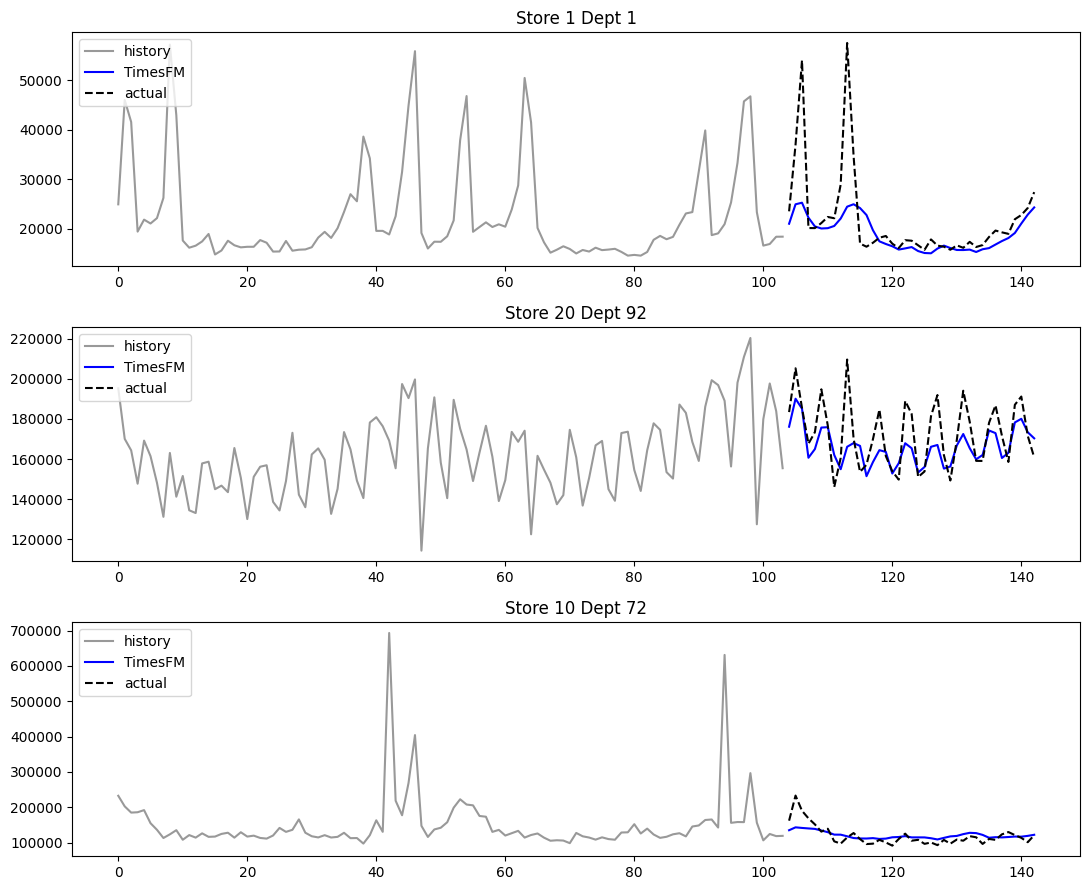

🏃 View run TimesFM_Demo at: https://dagshub.com/smama23/MLFinalProject.mlflow/#/experiments/4/runs/aa18ca45693c4151853921b70e92a15e
🧪 View experiment at: https://dagshub.com/smama23/MLFinalProject.mlflow/#/experiments/4
demo forecasts plotted


In [9]:
fold = next(f for f in FOLDS if f.name == "recent")
va = train[(train.Date >= fold.val_start) & (train.Date <= fold.val_end)]
panel = WalmartPanel(train, features, stores, lookback=52).fit(fold.cut)

demo_ids = [panel.key_pos_[k] for k in [(1, 1), (20, 92), (10, 72)] if k in panel.key_pos_]
ctx = [panel.series_history(i).astype(np.float32) for i in demo_ids]
pt, _ = model.forecast(horizon=HORIZON, inputs=ctx)

with mlflow.start_run(run_name="TimesFM_Demo"):
    fig, ax = plt.subplots(len(demo_ids), 1, figsize=(11, 3 * len(demo_ids)))
    ax = np.atleast_1d(ax)
    fdates = panel.forecast_dates()
    for r, i in enumerate(demo_ids):
        s, d = panel.keys_[i]
        hist = panel.series_history(i)
        actual = (va[(va.Store == s) & (va.Dept == d)].set_index("Date")
                  .Weekly_Sales.reindex(fdates))
        ax[r].plot(range(len(hist)), hist, color="0.6", label="history")
        base = len(hist)
        ax[r].plot(range(base, base + HORIZON), pt[r, :HORIZON], "b-", label="TimesFM")
        ax[r].plot(range(base, base + HORIZON), actual.values, "k--", label="actual")
        ax[r].set_title(f"Store {s} Dept {d}"); ax[r].legend(loc="upper left")
    fig.tight_layout()
    p = ROOT / "docs" / "timesfm_demo.png"; fig.savefig(p, dpi=110); plt.show()
    mlflow.log_artifact(str(p))
print("demo forecasts plotted")

## `TimesFM_CV`

In [10]:
import time
with mlflow.start_run(run_name="TimesFM_CV"):
    mlflow.log_params({"model": "google/timesfm-2.5-200m-pytorch", "mode": "zero-shot",
                       "horizon": HORIZON, "fold": "recent"})
    t0 = time.time()
    hp, nfit = timesfm_forecast(model, panel)
    pred = PrecomputedForecaster(panel, hp)(va)
    s = score_fold(va.Weekly_Sales, pred, va)
    mlflow.log_metric("wmae_recent", s["wmae"])
    mlflow.log_metric("series_forecast", nfit)
    mlflow.log_metric("forecast_minutes", (time.time() - t0) / 60)
    print(f"\nTimesFM zero-shot WMAE (recent) = {s['wmae']:.1f}   naive = {BASELINE['recent']:.1f}  "
          f"({100*(1-s['wmae']/BASELINE['recent']):+.1f}%)")
pd.Series(s).round(1)

  forecast 512/3211
  forecast 1024/3211
  forecast 1536/3211
  forecast 2048/3211
  forecast 2560/3211
  forecast 3072/3211
  forecast 3211/3211

TimesFM zero-shot WMAE (recent) = 1679.1   naive = 1807.2  (+7.1%)
🏃 View run TimesFM_CV at: https://dagshub.com/smama23/MLFinalProject.mlflow/#/experiments/4/runs/597002b0207d4ccb8d4d6951633cacb9
🧪 View experiment at: https://dagshub.com/smama23/MLFinalProject.mlflow/#/experiments/4


,0
wmae,1679.1
mae,1619.1
mae_holiday,1969.7
mae_nonholiday,1600.0
bias,-771.9
mae_superbowl,2072.3
mae_laborday,1865.9


## `TimesFM_Final`

In [11]:
panel_full = WalmartPanel(train, features, stores, lookback=52).fit()
with mlflow.start_run(run_name="TimesFM_Final") as final_run:
    mlflow.log_params({"model": "google/timesfm-2.5-200m-pytorch", "mode": "zero-shot",
                       "trained_on": "none (pretrained, zero-shot)"})
    hp_full, nfit = timesfm_forecast(model, panel_full)
    forecaster = PrecomputedForecaster(panel_full, hp_full)
    y_pred = forecaster(test)
    print(f"\nforecast {nfit}/{panel_full.n_series_} series; predictions n={len(y_pred)} "
          f"mean={y_pred.mean():.0f} finite={np.isfinite(y_pred).all()}")

    from walmart_prep import WalmartFeatureBuilder
    g = (WalmartFeatureBuilder(features, stores)
         .fit(train.drop(columns=["Weekly_Sales"]), train.Weekly_Sales).xmas_profile_)
    frame, verdict = december_shape_report(train, test, y_pred, g)
    print(frame.to_string(index=False, float_format=lambda v: f"{v:8.3f}"))
    print(f"\npredicted peak {verdict['peak_predicted']} | implied {verdict['peak_implied']}")
    print("GATE:", "PASS" if verdict["passed"] else "REVIEW -- " + "; ".join(verdict["problems"]))
    mlflow.log_metric("december_xmas_gap_pct", verdict["xmas_gap_pct"])
    mlflow.log_metric("december_gate_passed", int(verdict["passed"]))

    logged_model = mlflow.pyfunc.log_model(
        name="model", python_model=forecaster,
        code_paths=[str(ROOT / "src" / "walmart_prep.py"), str(ROOT / "src" / "walmart_panel.py")],
        input_example=test.head(3))
    MODEL_URI = logged_model.model_uri
    sub = make_submission(test, y_pred, ROOT / "submissions" / "timesfm.csv")
    mlflow.log_artifact(str(ROOT / "submissions" / "timesfm.csv"))
    FINAL_RUN_ID = final_run.info.run_id

print(f"\nrun_id = {FINAL_RUN_ID}\nmodel_uri = {MODEL_URI}")
sub.head()

  forecast 512/3258
  forecast 1024/3258
  forecast 1536/3258
  forecast 2048/3258
  forecast 2560/3258
  forecast 3072/3258
  forecast 3258/3258

forecast 3258/3331 series; predictions n=115064 mean=16056 finite=True
      week  k_end  predicted  implied  gap_pct
2012-11-30    -25      1.071    0.969   10.539
2012-12-07    -18      1.125    1.109    1.393
2012-12-14    -11      1.179    1.208   -2.356
2012-12-21     -4      1.207    1.489  -18.952
2012-12-28      3      1.072    1.243  -13.755
2013-01-04     10      1.000    0.919    8.840

predicted peak 2012-12-21 | implied 2012-12-21
GATE: REVIEW -- Christmas week off by -13.8%, beyond the profile's uncertainty


2026/07/11 12:27:58 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/07/11 12:27:58 INFO mlflow.pyfunc: Inferring model signature from input example
/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64)

🏃 View run TimesFM_Final at: https://dagshub.com/smama23/MLFinalProject.mlflow/#/experiments/4/runs/17c9c320a2a14ed581d2540c07498ba9
🧪 View experiment at: https://dagshub.com/smama23/MLFinalProject.mlflow/#/experiments/4

run_id = 17c9c320a2a14ed581d2540c07498ba9
model_uri = models:/m-ab5963d77b2a48a888a05fe8b3c2bd2c


,Id,Weekly_Sales
0,1_1_2012-11-02,29630.830078
1,1_1_2012-11-09,24433.853516
2,1_1_2012-11-16,21384.291016
3,1_1_2012-11-23,21034.990234
4,1_1_2012-11-30,25151.812500


In [12]:
from mlflow import MlflowClient
loaded = mlflow.pyfunc.load_model(MODEL_URI)
reloaded = np.asarray(loaded.predict(test))
print("max |reloaded - original| =", float(np.abs(reloaded - y_pred).max()))
assert np.allclose(reloaded, y_pred, atol=1e-3), "the logged pyfunc must reproduce its predictions"
print("pyfunc round-trip OK")

mv = mlflow.register_model(MODEL_URI, REGISTERED_MODEL_NAME)
print(f"registered {mv.name} version {mv.version}")
try:
    MlflowClient().set_registered_model_alias(mv.name, "timesfm", mv.version)
    print(f"alias 'timesfm' -> version {mv.version}")
except Exception as e:
    print("alias not set (optional):", str(e)[:80])

max |reloaded - original| = 0.0
pyfunc round-trip OK


Registered model 'WalmartSalesForecast' already exists. Creating a new version of this model...
2026/07/11 12:28:21 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: WalmartSalesForecast, version 6
Created version '6' of model 'WalmartSalesForecast'.


registered WalmartSalesForecast version 6
alias 'timesfm' -> version 6
